In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit

In [4]:
gdp_data = pd.read_csv("china_gdp.csv")
gdp_data.head()

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10


In [5]:
def logistic(x, a, b, c):
    return c / (1 + np.exp(-a * (x - b)))

In [6]:
X = gdp_data["Year"].values
y = gdp_data["Value"].values

In [7]:
x_norm = (X - X.min()) / (X.max() - X.min())

In [8]:
popt, pcov = curve_fit(logistic, x_norm, y, p0=[0.5, 0.5, 1e13])

In [9]:
y_pred = logistic(x_norm, *popt)

In [10]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("📊 MODEL EVALUATION METRICS (NON-LINEAR REGRESSION)")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

📊 MODEL EVALUATION METRICS (NON-LINEAR REGRESSION)
Mean Absolute Error (MAE): 163274110888.25
Mean Squared Error (MSE): 38116626354002580209664.00
Root Mean Squared Error (RMSE): 195234798009.99
R² Score: 0.9938


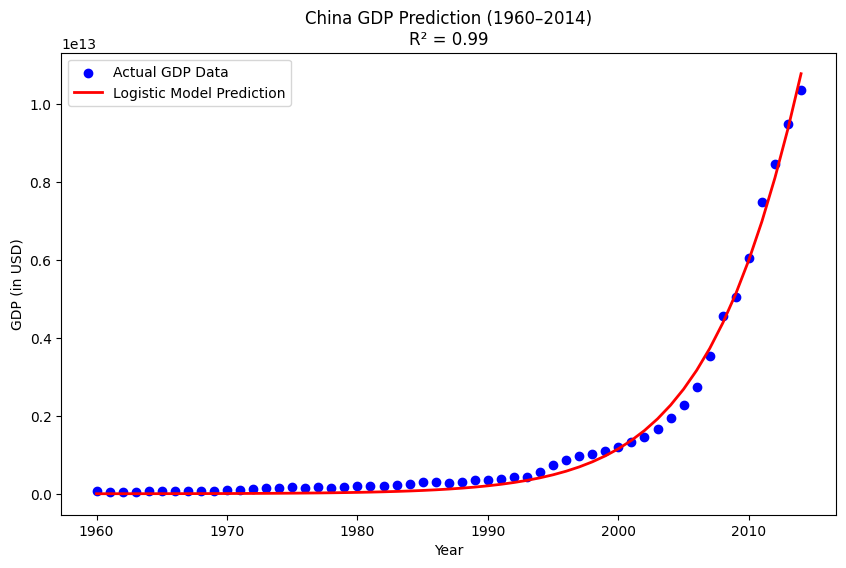

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color="blue", label="Actual GDP Data")
plt.plot(X, y_pred, color="red", linewidth=2, label="Logistic Model Prediction")
plt.xlabel("Year")
plt.ylabel("GDP (in USD)")
plt.title(f"China GDP Prediction (1960–2014)\nR² = {r2:.2f}")
plt.legend()
plt.show()